In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
path = '../datasets/bitly_usagov/example.txt'

In [3]:
with open(path) as f:
    print(f.readline())

{ "a": "Mozilla\/5.0 (Windows NT 6.1; WOW64) AppleWebKit\/535.11 (KHTML, like Gecko) Chrome\/17.0.963.78 Safari\/535.11", "c": "US", "nk": 1, "tz": "America\/New_York", "gr": "MA", "g": "A6qOVH", "h": "wfLQtf", "l": "orofrog", "al": "en-US,en;q=0.8", "hh": "1.usa.gov", "r": "http:\/\/www.facebook.com\/l\/7AQEFzjSi\/1.usa.gov\/wfLQtf", "u": "http:\/\/www.ncbi.nlm.nih.gov\/pubmed\/22415991", "t": 1331923247, "hc": 1331822918, "cy": "Danvers", "ll": [ 42.576698, -70.954903 ] }



In [4]:
import json
with open(path) as f:
    records = [json.loads(line) for line in f]

In [5]:
records[0]

{'a': 'Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebKit/535.11 (KHTML, like Gecko) Chrome/17.0.963.78 Safari/535.11',
 'c': 'US',
 'nk': 1,
 'tz': 'America/New_York',
 'gr': 'MA',
 'g': 'A6qOVH',
 'h': 'wfLQtf',
 'l': 'orofrog',
 'al': 'en-US,en;q=0.8',
 'hh': '1.usa.gov',
 'r': 'http://www.facebook.com/l/7AQEFzjSi/1.usa.gov/wfLQtf',
 'u': 'http://www.ncbi.nlm.nih.gov/pubmed/22415991',
 't': 1331923247,
 'hc': 1331822918,
 'cy': 'Danvers',
 'll': [42.576698, -70.954903]}

In [6]:
time_zones = [rec['tz'] for rec in records if 'tz' in rec]

In [7]:
time_zones[:10]

['America/New_York',
 'America/Denver',
 'America/New_York',
 'America/Sao_Paulo',
 'America/New_York',
 'America/New_York',
 'Europe/Warsaw',
 '',
 '',
 '']

In [8]:
def get_counts(sequence):
    counts = {}
    for x in sequence:
        if x in counts:
            counts[x] +=1
        else:
            counts[x] = 1
    return counts

In [9]:
from collections import defaultdict
def get_counts2(sequence):
    counts = defaultdict(int)
    for x in sequence:
        counts[x] += 1
    return counts

In [10]:
counts = get_counts(time_zones)

In [11]:
counts['America/New_York']

1251

In [12]:
len(time_zones)

3440

In [13]:
def top_counts(counts_dict, n=10):
    value_key_pairs = [(counts, tz) for tz, count in counts_dict.items()]
    value_key_pairs.sort()
    return value_key_pairs[-n:]

In [14]:
top_counts(counts)

[({'America/New_York': 1251,
   'America/Denver': 191,
   'America/Sao_Paulo': 33,
   'Europe/Warsaw': 16,
   '': 521,
   'America/Los_Angeles': 382,
   'Asia/Hong_Kong': 10,
   'Europe/Rome': 27,
   'Africa/Ceuta': 2,
   'Europe/Madrid': 35,
   'Asia/Kuala_Lumpur': 3,
   'Asia/Nicosia': 1,
   'Europe/London': 74,
   'Pacific/Honolulu': 36,
   'America/Chicago': 400,
   'Europe/Malta': 2,
   'Europe/Lisbon': 8,
   'Europe/Paris': 14,
   'Europe/Copenhagen': 5,
   'America/Mazatlan': 1,
   'Europe/Dublin': 3,
   'Europe/Brussels': 4,
   'America/Vancouver': 12,
   'Europe/Amsterdam': 22,
   'Europe/Prague': 10,
   'Europe/Stockholm': 14,
   'America/Anchorage': 5,
   'Asia/Bangkok': 6,
   'Europe/Berlin': 28,
   'America/Rainy_River': 25,
   'Europe/Budapest': 5,
   'Asia/Tokyo': 37,
   'Europe/Vienna': 6,
   'America/Phoenix': 20,
   'Asia/Jerusalem': 3,
   'Asia/Karachi': 3,
   'America/Bogota': 3,
   'America/Indianapolis': 20,
   'America/Montreal': 9,
   'Asia/Calcutta': 9,
   'Eur

In [15]:
from collections import Counter

In [16]:
counts = Counter(time_zones)

In [17]:
counts.most_common(10)

[('America/New_York', 1251),
 ('', 521),
 ('America/Chicago', 400),
 ('America/Los_Angeles', 382),
 ('America/Denver', 191),
 ('Europe/London', 74),
 ('Asia/Tokyo', 37),
 ('Pacific/Honolulu', 36),
 ('Europe/Madrid', 35),
 ('America/Sao_Paulo', 33)]

In [18]:
frame = pd.DataFrame(records)

In [19]:
frame.info()

<class 'pandas.DataFrame'>
RangeIndex: 3560 entries, 0 to 3559
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   a            3440 non-null   str    
 1   c            2919 non-null   str    
 2   nk           3440 non-null   float64
 3   tz           3440 non-null   str    
 4   gr           2919 non-null   str    
 5   g            3440 non-null   str    
 6   h            3440 non-null   str    
 7   l            3440 non-null   str    
 8   al           3094 non-null   str    
 9   hh           3440 non-null   str    
 10  r            3440 non-null   str    
 11  u            3440 non-null   str    
 12  t            3440 non-null   float64
 13  hc           3440 non-null   float64
 14  cy           2919 non-null   str    
 15  ll           2919 non-null   object 
 16  _heartbeat_  120 non-null    float64
 17  kw           93 non-null     str    
dtypes: float64(4), object(1), str(13)
memory usage: 500.8+ KB


In [20]:
frame['tz'].head()

0     America/New_York
1       America/Denver
2     America/New_York
3    America/Sao_Paulo
4     America/New_York
Name: tz, dtype: str

In [21]:
tz_counts = frame['tz'].value_counts()

In [22]:
tz_counts.head()

tz
America/New_York       1251
                        521
America/Chicago         400
America/Los_Angeles     382
America/Denver          191
Name: count, dtype: int64

In [23]:
clean_tz = frame['tz'].fillna('Missing')

In [24]:
clean_tz[clean_tz == ''] = 'Unknown'

In [25]:
tz_counts = clean_tz.value_counts()

In [26]:
tz_counts.head()

tz
America/New_York       1251
Unknown                 521
America/Chicago         400
America/Los_Angeles     382
America/Denver          191
Name: count, dtype: int64

<Axes: ylabel='tz'>

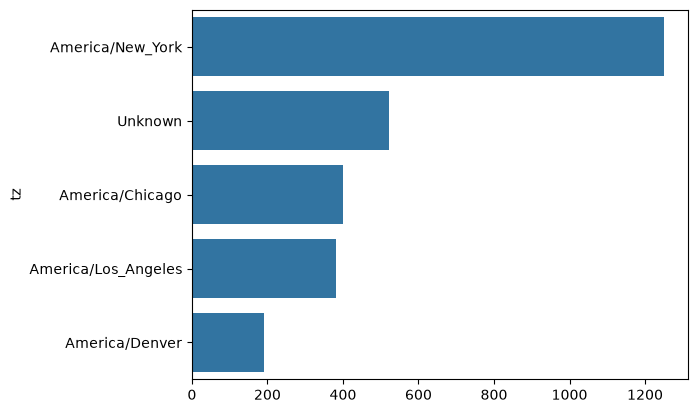

In [27]:
subset = tz_counts.head()
sns.barplot(y=subset.index, x=subset.to_numpy())

In [28]:
frame['a'][1]

'GoogleMaps/RochesterNY'

In [29]:
frame['a'][50]

'Mozilla/5.0 (Windows NT 5.1; rv:10.0.2) Gecko/20100101 Firefox/10.0.2'

In [30]:
frame['a'][51][:50]

'Mozilla/5.0 (Linux; U; Android 2.2.2; en-us; LG-P9'

In [31]:
results = pd.Series([x.split()[0] for x in frame['a'].dropna()])

In [32]:
results.head(5)

0               Mozilla/5.0
1    GoogleMaps/RochesterNY
2               Mozilla/4.0
3               Mozilla/5.0
4               Mozilla/5.0
dtype: str

In [33]:
results.value_counts().head(8)

Mozilla/5.0                 2594
Mozilla/4.0                  601
GoogleMaps/RochesterNY       121
Opera/9.80                    34
TEST_INTERNET_AGENT           24
GoogleProducer                21
Mozilla/6.0                    5
BlackBerry8520/5.0.0.681       4
Name: count, dtype: int64

In [34]:
cframe = frame[frame['a'].notna()].copy()

In [35]:
cframe['os'] = np.where(cframe['a'].str.contains('Windows'),
                        'Windows', 'Not Windows')

In [36]:
cframe['os'].head(5)

0        Windows
1    Not Windows
2        Windows
3    Not Windows
4        Windows
Name: os, dtype: str

In [37]:
by_tz_os = cframe.groupby(['tz', 'os'])

In [38]:
agg_counts = by_tz_os.size().unstack().fillna(0)

In [39]:
agg_counts.head()

os,Not Windows,Windows
tz,,
,245.0,276.0
Africa/Cairo,0.0,3.0
Africa/Casablanca,0.0,1.0
Africa/Ceuta,0.0,2.0
Africa/Johannesburg,0.0,1.0


In [45]:
indexer = agg_counts.sum(axis='columns').argsort()

In [46]:
indexer.values[:10]

array([ 2,  7,  5,  4, 14, 11,  9,  8, 24, 26])

In [47]:
count_subset = agg_counts.take(indexer[-10:])

In [49]:
count_subset

os,Not Windows,Windows
tz,,
America/Sao_Paulo,13.0,20.0
Europe/Madrid,16.0,19.0
Pacific/Honolulu,0.0,36.0
Asia/Tokyo,2.0,35.0
Europe/London,43.0,31.0
America/Denver,132.0,59.0
America/Los_Angeles,130.0,252.0
America/Chicago,115.0,285.0
,245.0,276.0


In [50]:
agg_counts.sum(axis='columns').nlargest(10)

tz
America/New_York       1251.0
                        521.0
America/Chicago         400.0
America/Los_Angeles     382.0
America/Denver          191.0
Europe/London            74.0
Asia/Tokyo               37.0
Pacific/Honolulu         36.0
Europe/Madrid            35.0
America/Sao_Paulo        33.0
dtype: float64

<Axes: xlabel='total', ylabel='tz'>

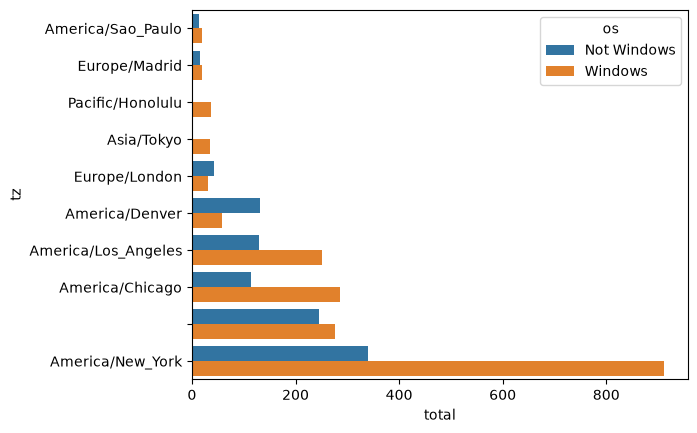

In [51]:
count_subset = count_subset.stack()
count_subset.name = 'total'
count_subset = count_subset.reset_index()
count_subset.head()
sns.barplot(x='total', y='tz', hue='os', data=count_subset)

In [52]:
def norm_total(group):
    group['normed_total'] = group['total'] / group['total'].sum()
    return group

results = count_subset.groupby('tz').apply(norm_total)

<Axes: xlabel='normed_total', ylabel='tz'>

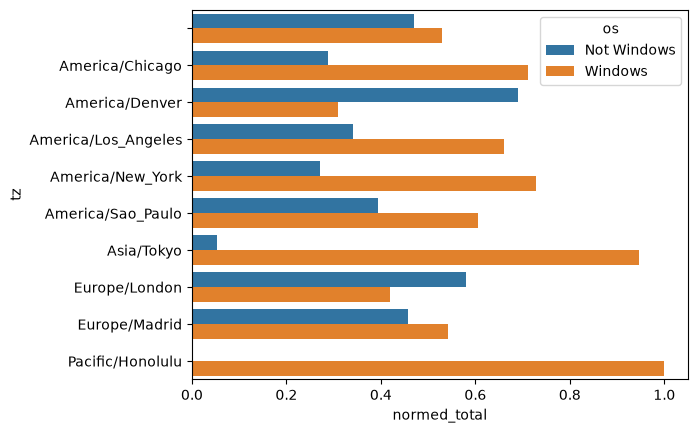

In [53]:
sns.barplot(x='normed_total', y='tz', hue='os', data=results)

In [54]:
g = count_subset.groupby('tz')

In [55]:
results2 = count_subset['total'] / g['total'].transform('sum')

In [58]:
unames = ['user_id', 'gender', 'age', 'occupation', 'zip']
users = pd.read_table('../datasets/movielens/users.dat', sep='::',
                      header=None, names=unames, engine='python')
rnames = ['user_id', 'movie_id', 'rating', 'timestamp']

ratings = pd.read_table('../datasets/movielens/ratings.dat', sep='::',
                        header=None, names=rnames, engine='python')

mnames = ['movie_id', 'title', 'genres']
movies = pd.read_table('../datasets/movielens/movies.dat', sep='::',
                       header=None, names=mnames, engine='python')


In [59]:
users.head(5)

,user_id,gender,age,occupation,zip
0,1,F,1,10,48067
1,2,M,56,16,70072
2,3,M,25,15,55117
3,4,M,45,7,02460
4,5,M,25,20,55455


In [60]:
ratings.head(5)

,user_id,movie_id,rating,timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291


In [63]:
movies.head(5)

,movie_id,title,genres
0,1,Toy Story (1995),Animation|Children's|Comedy
1,2,Jumanji (1995),Adventure|Children's|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama
4,5,Father of the Bride Part II (1995),Comedy


In [64]:
ratings

,user_id,movie_id,rating,timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291
...,...,...,...,...
1000204,6040,1091,1,956716541
1000205,6040,1094,5,956704887
1000206,6040,562,5,956704746
1000207,6040,1096,4,956715648


In [65]:
data = pd.merge(pd.merge(ratings, users), movies)

In [66]:
data

,user_id,movie_id,rating,timestamp,gender,age,occupation,zip,title,genres
0,1,1193,5,978300760,F,1,10,48067,One Flew Over the Cuckoo's Nest (1975),Drama
1,1,661,3,978302109,F,1,10,48067,James and the Giant Peach (1996),Animation|Children's|Musical
2,1,914,3,978301968,F,1,10,48067,My Fair Lady (1964),Musical|Romance
3,1,3408,4,978300275,F,1,10,48067,Erin Brockovich (2000),Drama
4,1,2355,5,978824291,F,1,10,48067,"Bug's Life, A (1998)",Animation|Children's|Comedy
...,...,...,...,...,...,...,...,...,...,...
1000204,6040,1091,1,956716541,M,25,6,11106,Weekend at Bernie's (1989),Comedy
1000205,6040,1094,5,956704887,M,25,6,11106,"Crying Game, The (1992)",Drama|Romance|War
1000206,6040,562,5,956704746,M,25,6,11106,Welcome to the Dollhouse (1995),Comedy|Drama
1000207,6040,1096,4,956715648,M,25,6,11106,Sophie's Choice (1982),Drama


In [67]:
data.iloc[0]

user_id                                            1
movie_id                                        1193
rating                                             5
timestamp                                  978300760
gender                                             F
age                                                1
occupation                                        10
zip                                            48067
title         One Flew Over the Cuckoo's Nest (1975)
genres                                         Drama
Name: 0, dtype: object

In [68]:
mean_ratings = data.pivot_table('rating', index='title',
                                columns='gender', aggfunc='mean')

In [69]:
mean_ratings.head(5)

gender,F,M
title,,
"$1,000,000 Duck (1971)",3.375000,2.761905
'Night Mother (1986),3.388889,3.352941
'Til There Was You (1997),2.675676,2.733333
"'burbs, The (1989)",2.793478,2.962085
...And Justice for All (1979),3.828571,3.689024


In [70]:
ratings_by_title = data.groupby('title').size()

In [71]:
ratings_by_title.head()

title
$1,000,000 Duck (1971)            37
'Night Mother (1986)              70
'Til There Was You (1997)         52
'burbs, The (1989)               303
...And Justice for All (1979)    199
dtype: int64

In [72]:
active_titles = ratings_by_title.index[ratings_by_title >= 250]

In [73]:
active_titles

Index([''burbs, The (1989)', '10 Things I Hate About You (1999)',
       '101 Dalmatians (1961)', '101 Dalmatians (1996)', '12 Angry Men (1957)',
       '13th Warrior, The (1999)', '2 Days in the Valley (1996)',
       '20,000 Leagues Under the Sea (1954)', '2001: A Space Odyssey (1968)',
       '2010 (1984)',
       ...
       'X-Men (2000)', 'Year of Living Dangerously (1982)',
       'Yellow Submarine (1968)', 'You've Got Mail (1998)',
       'Young Frankenstein (1974)', 'Young Guns (1988)',
       'Young Guns II (1990)', 'Young Sherlock Holmes (1985)',
       'Zero Effect (1998)', 'eXistenZ (1999)'],
      dtype='str', name='title', length=1216)

In [74]:
mean_ratings = mean_ratings.loc[active_titles]

In [75]:
mean_ratings

gender,F,M
title,,
"'burbs, The (1989)",2.793478,2.962085
10 Things I Hate About You (1999),3.646552,3.311966
101 Dalmatians (1961),3.791444,3.500000
101 Dalmatians (1996),3.240000,2.911215
12 Angry Men (1957),4.184397,4.328421
...,...,...
Young Guns (1988),3.371795,3.425620
Young Guns II (1990),2.934783,2.904025
Young Sherlock Holmes (1985),3.514706,3.363344


In [76]:
top_female_ratings = mean_ratings.sort_values('F', ascending=False)

In [77]:
top_female_ratings.head()

gender,F,M
title,,
"Close Shave, A (1995)",4.644444,4.473795
"Wrong Trousers, The (1993)",4.588235,4.478261
Sunset Blvd. (a.k.a. Sunset Boulevard) (1950),4.572650,4.464589
Wallace & Gromit: The Best of Aardman Animation (1996),4.563107,4.385075
Schindler's List (1993),4.562602,4.491415


In [78]:
mean_ratings['diff'] = mean_ratings['M'] - mean_ratings['F']

In [79]:
sorted_by_diff = mean_ratings.sort_values('diff')

In [80]:
sorted_by_diff.head()

gender,F,M,diff
title,,,
Dirty Dancing (1987),3.790378,2.959596,-0.830782
Jumpin' Jack Flash (1986),3.254717,2.578358,-0.676359
Grease (1978),3.975265,3.367041,-0.608224
Little Women (1994),3.870588,3.321739,-0.548849
Steel Magnolias (1989),3.901734,3.365957,-0.535777


In [81]:
sorted_by_diff[::-1].head()

gender,F,M,diff
title,,,
"Good, The Bad and The Ugly, The (1966)",3.494949,4.221300,0.726351
"Kentucky Fried Movie, The (1977)",2.878788,3.555147,0.676359
Dumb & Dumber (1994),2.697987,3.336595,0.638608
"Longest Day, The (1962)",3.411765,4.031447,0.619682
"Cable Guy, The (1996)",2.250000,2.863787,0.613787


In [82]:
rating_std_by_title = data.groupby('title')['rating'].std()

In [85]:
rating_std_by_title = rating_std_by_title.loc[active_titles]

In [86]:
rating_std_by_title.head()

title
'burbs, The (1989)                   1.107760
10 Things I Hate About You (1999)    0.989815
101 Dalmatians (1961)                0.982103
101 Dalmatians (1996)                1.098717
12 Angry Men (1957)                  0.812731
Name: rating, dtype: float64

In [87]:
rating_std_by_title.sort_values(ascending=False)[:10]

title
Dumb & Dumber (1994)                     1.321333
Blair Witch Project, The (1999)          1.316368
Natural Born Killers (1994)              1.307198
Tank Girl (1995)                         1.277695
Rocky Horror Picture Show, The (1975)    1.260177
Eyes Wide Shut (1999)                    1.259624
Evita (1996)                             1.253631
Billy Madison (1995)                     1.249970
Fear and Loathing in Las Vegas (1998)    1.246408
Bicentennial Man (1999)                  1.245533
Name: rating, dtype: float64

In [88]:
movies['genres'].head()

0     Animation|Children's|Comedy
1    Adventure|Children's|Fantasy
2                  Comedy|Romance
3                    Comedy|Drama
4                          Comedy
Name: genres, dtype: str

In [90]:
movies['genres'].head().str.split('|')

0     [Animation, Children's, Comedy]
1    [Adventure, Children's, Fantasy]
2                   [Comedy, Romance]
3                     [Comedy, Drama]
4                            [Comedy]
Name: genres, dtype: object

In [91]:
movies['genre'] = movies.pop('genres').str.split('|')

In [92]:
movies.head()

,movie_id,title,genre
0,1,Toy Story (1995),"[Animation, Children's, Comedy]"
1,2,Jumanji (1995),"[Adventure, Children's, Fantasy]"
2,3,Grumpier Old Men (1995),"[Comedy, Romance]"
3,4,Waiting to Exhale (1995),"[Comedy, Drama]"
4,5,Father of the Bride Part II (1995),[Comedy]


In [93]:
movies_exploded = movies.explode('genre')

In [94]:
movies_exploded[:10]

,movie_id,title,genre
0,1,Toy Story (1995),Animation
0,1,Toy Story (1995),Children's
0,1,Toy Story (1995),Comedy
1,2,Jumanji (1995),Adventure
1,2,Jumanji (1995),Children's
1,2,Jumanji (1995),Fantasy
2,3,Grumpier Old Men (1995),Comedy
2,3,Grumpier Old Men (1995),Romance
3,4,Waiting to Exhale (1995),Comedy
3,4,Waiting to Exhale (1995),Drama


In [95]:
ratings_with_genre = pd.merge(pd.merge(movies_exploded, ratings), users)

In [96]:
ratings_with_genre.iloc[00]

movie_id                     1
title         Toy Story (1995)
genre                Animation
user_id                      1
rating                       5
timestamp            978824268
gender                       F
age                          1
occupation                  10
zip                      48067
Name: 0, dtype: object

In [97]:
genre_ratings = (ratings_with_genre.groupby(['genre', 'age'])
                 ['rating'].mean()
                 .unstack('age'))

In [98]:
genre_ratings[:10]

age,1,18,25,35,45,50,56
genre,,,,,,,
Action,3.506385,3.447097,3.453358,3.538107,3.528543,3.611333,3.610709
Adventure,3.449975,3.408525,3.443163,3.515291,3.528963,3.628163,3.649064
Animation,3.476113,3.624014,3.701228,3.740545,3.734856,3.780020,3.756233
Children's,3.241642,3.294257,3.426873,3.518423,3.527593,3.556555,3.621822
Comedy,3.497491,3.460417,3.490385,3.561984,3.591789,3.646868,3.650949
Crime,3.710170,3.668054,3.680321,3.733736,3.750661,3.810688,3.832549
Documentary,3.730769,3.865865,3.946690,3.953747,3.966521,3.908108,3.961538
Drama,3.794735,3.721930,3.726428,3.782512,3.784356,3.878415,3.933465
Fantasy,3.317647,3.353778,3.452484,3.482301,3.532468,3.581570,3.532700


In [100]:
names1880 = pd.read_csv('../datasets/babynames/yob1880.txt',
                        names=['name', 'sex', 'birth'])

In [101]:
names1880

,name,sex,birth
0,Mary,F,7065
1,Anna,F,2604
2,Emma,F,2003
3,Elizabeth,F,1939
4,Minnie,F,1746
...,...,...,...
1995,Woodie,M,5
1996,Worthy,M,5
1997,Wright,M,5
1998,York,M,5


In [102]:
names1880.groupby('sex')['birth'].sum()

sex
F     90993
M    110493
Name: birth, dtype: int64

In [109]:
pieces = []
for year in range(1880, 2011):
    path = f'../datasets/babynames/yob{year}.txt'
    frame = pd.read_csv(path, names=['name', 'sex','births'])

    frame['year'] = year
    pieces.append(frame)

names = pd.concat(pieces, ignore_index=True)

In [110]:
names

,name,sex,births,year
0,Mary,F,7065,1880
1,Anna,F,2604,1880
2,Emma,F,2003,1880
3,Elizabeth,F,1939,1880
4,Minnie,F,1746,1880
...,...,...,...,...
1690779,Zymaire,M,5,2010
1690780,Zyonne,M,5,2010
1690781,Zyquarius,M,5,2010
1690782,Zyran,M,5,2010


In [111]:
total_births = names.pivot_table('births', index='year',
                                columns='sex', aggfunc=sum)

In [112]:
total_births.tail()

sex,F,M
year,,
2006,1896468,2050234
2007,1916888,2069242
2008,1883645,2032310
2009,1827643,1973359
2010,1759010,1898382


<Axes: title={'center': 'Total births by sex and year'}, xlabel='year'>

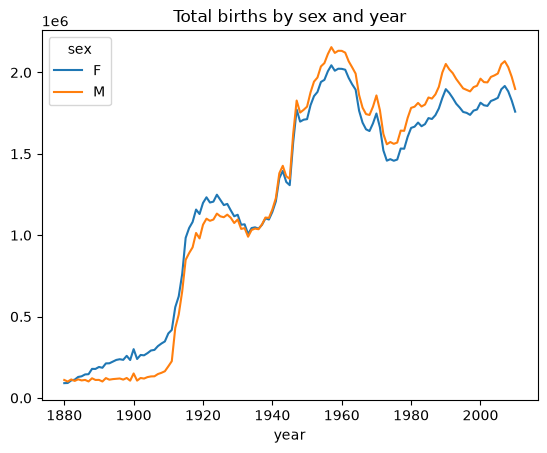

In [113]:
total_births.plot(title='Total births by sex and year')

In [114]:
def add_prop(group):
    group['prop'] = group['births'] / group['births'].sum()
    return group
names = names.groupby(['year', 'sex']).apply(add_prop)

In [115]:
names

name  births      prop
year sex                                     
1880 F   0             Mary    7065  0.077643
         1             Anna    2604  0.028618
         2             Emma    2003  0.022013
         3        Elizabeth    1939  0.021309
         4           Minnie    1746  0.019188
...                     ...     ...       ...
2010 M   1690779    Zymaire       5  0.000003
         1690780     Zyonne       5  0.000003
         1690781  Zyquarius       5  0.000003
         1690782      Zyran       5  0.000003
         1690783      Zzyzx       5  0.000003

[1690784 rows x 3 columns]

In [138]:
names.groupby(['year', 'sex'])['prop'].sum()

year  sex
1880  F      1.0
      M      1.0
1881  F      1.0
      M      1.0
1882  F      1.0
            ... 
2008  M      1.0
2009  F      1.0
      M      1.0
2010  F      1.0
      M      1.0
Name: prop, Length: 262, dtype: float64

In [ ]:
def get_top1000(group):
    return group.sort_values('births', ascending=False)[:1000]

top1000 = names.groupby(['year', 'sex'], as_index=False).apply(get_top1000)
top1000 = top1000.reset_index()

In [141]:
top1000 = top1000.drop(columns=['level_2'])
top1000.head()

,year,sex,name,births,prop
0,1880,F,Mary,7065,0.077643
1,1880,F,Anna,2604,0.028618
2,1880,F,Emma,2003,0.022013
3,1880,F,Elizabeth,1939,0.021309
4,1880,F,Minnie,1746,0.019188


In [142]:
boys = top1000[top1000['sex'] == 'M']

In [143]:
girls = top1000[top1000['sex'] == 'F']

In [144]:
total_births = top1000.pivot_table('births', index='year',
                                   columns = 'name',
                                   aggfunc=sum)

In [145]:
total_births.info()

<class 'pandas.DataFrame'>
Index: 131 entries, 1880 to 2010
Columns: 6862 entries, Aaden to Zuri
dtypes: float64(6862)
memory usage: 6.9 MB


In [146]:
subset = total_births[['John', 'Harry', 'Mary', 'Marilyn']]

array([<Axes: xlabel='year'>, <Axes: xlabel='year'>,
       <Axes: xlabel='year'>, <Axes: xlabel='year'>], dtype=object)

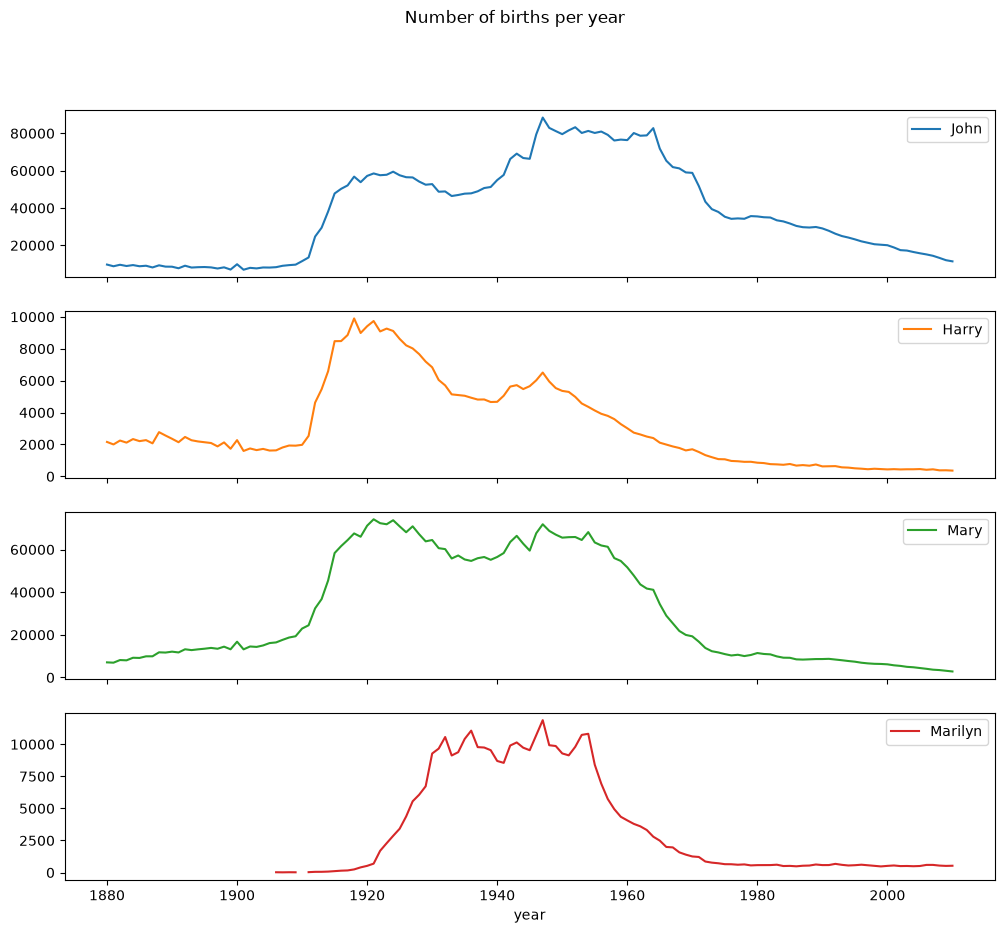

In [147]:
subset.plot(subplots=True, figsize=(12, 10),
            title='Number of births per year')

In [148]:
table = top1000.pivot_table('prop', index='year',
                            columns='sex', aggfunc=sum)

<Axes: title={'center': 'Sum of table1000.prop by year and sex'}, xlabel='year'>

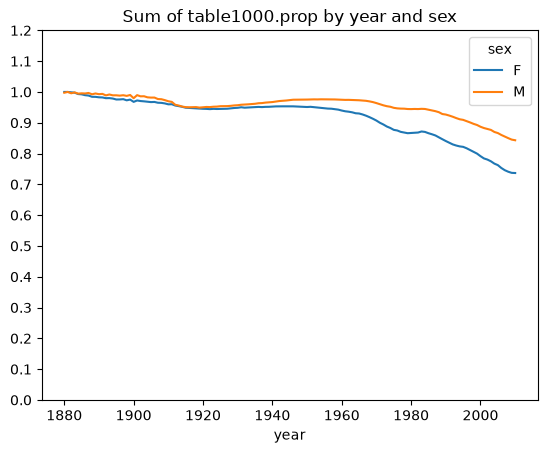

In [149]:
table.plot(title='Sum of table1000.prop by year and sex',
           yticks=np.linspace(0, 1.2, 13))

In [150]:
df = boys[boys['year'] == 2010]

In [151]:
df

,year,sex,name,births,prop
260877,2010,M,Jacob,21875,0.011523
260878,2010,M,Ethan,17866,0.009411
260879,2010,M,Michael,17133,0.009025
260880,2010,M,Jayden,17030,0.008971
260881,2010,M,William,16870,0.008887
...,...,...,...,...,...
261872,2010,M,Camilo,194,0.000102
261873,2010,M,Destin,194,0.000102
261874,2010,M,Jaquan,194,0.000102
261875,2010,M,Jaydan,194,0.000102


In [152]:
prop_cumsum = df['prop'].sort_values(ascending=False).cumsum()

In [153]:
prop_cumsum[:10]

260877    0.011523
260878    0.020934
260879    0.029959
260880    0.038930
260881    0.047817
260882    0.056579
260883    0.065155
260884    0.073414
260885    0.081528
260886    0.089621
Name: prop, dtype: float64

In [154]:
prop_cumsum.searchsorted(0.5)

np.int64(116)

In [155]:
df = boys[boys.year == 1900]

In [156]:
in1900 = df.sort_values('prop', ascending=False).prop.cumsum()

In [157]:
in1900.searchsorted(0.5) + 1

np.int64(25)

In [158]:
def get_quantile_count(group, q=0.5):
    group = group.sort_values('prop', ascending=False)
    return group.prop.cumsum().searchsorted(q) + 1

diversity = top1000.groupby(['year', 'sex']).apply(get_quantile_count)
diversity = diversity.unstack()

In [159]:
diversity.head()

sex,F,M
year,,
1880,38,14
1881,38,14
1882,38,15
1883,39,15
1884,39,16


<Axes: title={'center': 'Number of popular names in top 50%'}, xlabel='year'>

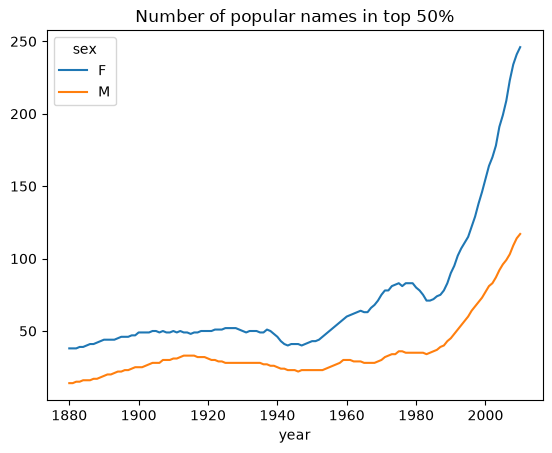

In [160]:
diversity.plot(title='Number of popular names in top 50%')

In [162]:
def get_last_letter(x):
    return x[-1]

last_letters = names['name'].map(get_last_letter)
last_letters.name = 'last_letter'

table = names.pivot_table('births', index=last_letters,
                          columns=['sex', 'year'], aggfunc=sum)

In [163]:
subtable = table.reindex(columns=[1910, 1960, 2010], level='year')

In [164]:
subtable.head()

sex                 F                            M                    
year             1910      1960      2010     1910      1960      2010
last_letter                                                           
a            108376.0  691247.0  670605.0    977.0    5204.0   28438.0
b                 NaN     694.0     450.0    411.0    3912.0   38859.0
c                 5.0      49.0     946.0    482.0   15476.0   23125.0
d              6750.0    3729.0    2607.0  22111.0  262112.0   44398.0
e            133569.0  435013.0  313833.0  28655.0  178823.0  129012.0

In [165]:
subtable.sum()

sex  year
F    1910     396416.0
     1960    2022062.0
     2010    1759010.0
M    1910     194198.0
     1960    2132588.0
     2010    1898382.0
dtype: float64

In [166]:
letter_prop = subtable / subtable.sum()

In [167]:
letter_prop

sex                 F                             M                    
year             1910      1960      2010      1910      1960      2010
last_letter                                                            
a            0.273390  0.341853  0.381240  0.005031  0.002440  0.014980
b                 NaN  0.000343  0.000256  0.002116  0.001834  0.020470
c            0.000013  0.000024  0.000538  0.002482  0.007257  0.012181
d            0.017028  0.001844  0.001482  0.113858  0.122908  0.023387
e            0.336941  0.215133  0.178415  0.147556  0.083853  0.067959
f                 NaN  0.000010  0.000055  0.000783  0.004325  0.001188
g            0.000144  0.000157  0.000374  0.002250  0.009488  0.001404
h            0.051529  0.036224  0.075852  0.045562  0.037907  0.051670
i            0.001526  0.039965  0.031734  0.000844  0.000603  0.022628
j                 NaN       NaN  0.000090       NaN       NaN  0.000769
k            0.000121  0.000156  0.000356  0.036581  0.049384  0.018541
l            0.043189  0.033867  0.026356  0.065016  0.104904  0.070367
m            0.001201  0.008613  0.002588  0.058044  0.033827  0.024657
n            0.079240  0.130687  0.140210  0.143415  0.152522  0.362771
o            0.001660  0.002439  0.001243  0.017065  0.012829  0.042681
p            0.000018  0.000023  0.000020  0.003172  0.005675  0.001269
q                 NaN       NaN  0.000030       NaN       NaN  0.000180
r            0.013390  0.006764  0.018025  0.064481  0.031034  0.087477
s            0.039042  0.012764  0.013332  0.130815  0.102730  0.065145
t            0.027438  0.015201  0.007830  0.072879  0.065655  0.022861
u            0.000684  0.000574  0.000417  0.000124  0.000057  0.001221
v                 NaN  0.000060  0.000117  0.000113  0.000037  0.001434
w            0.000020  0.000031  0.001182  0.006329  0.007711  0.016148
x            0.000015  0.000037  0.000727  0.003965  0.001851  0.008614
y            0.110972  0.152569  0.116828  0.077349  0.160987  0.058168
z            0.002439  0.000659  0.000704  0.000170  0.000184  0.001831

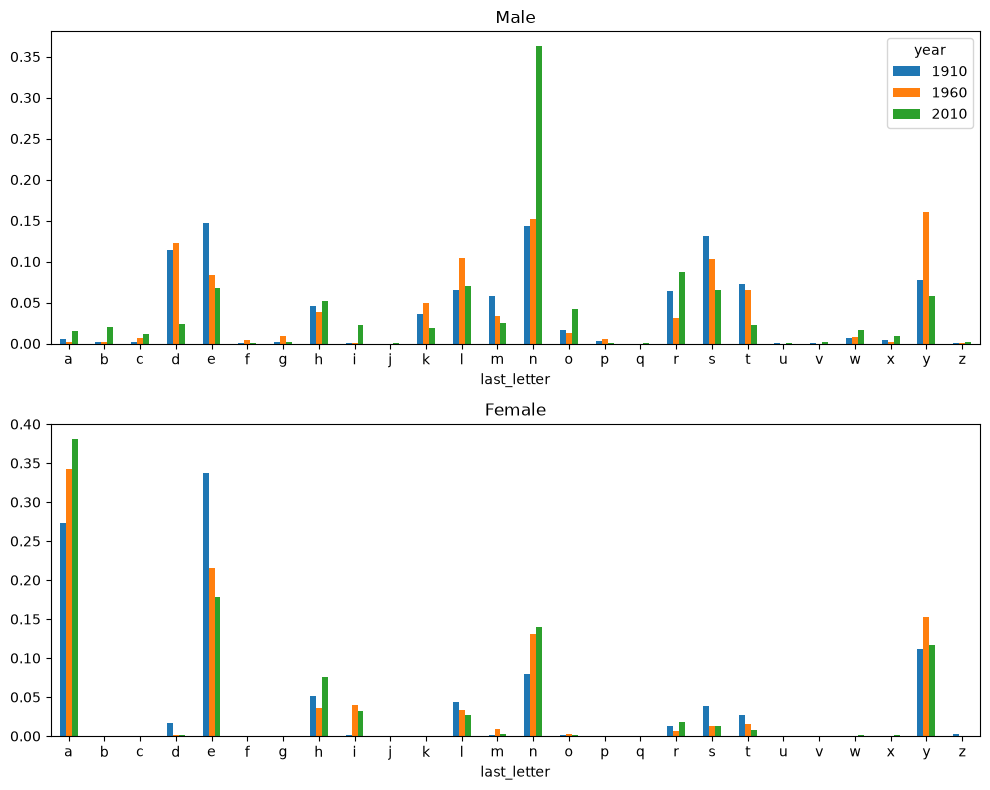

In [173]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(10, 8))
letter_prop['M'].plot(kind='bar', rot=0, ax=axes[0], title='Male')
letter_prop['F'].plot(kind='bar', rot=0, ax=axes[1], title='Female',
                      legend=False)
fig.tight_layout()

In [174]:
letter_prop = table / table.sum()

In [175]:
dny_ts = letter_prop.loc[['d', 'n', 'y'], 'M'].T

In [176]:
dny_ts.head()

last_letter,d,n,y
year,,,
1880,0.083055,0.153213,0.075760
1881,0.083247,0.153214,0.077451
1882,0.085340,0.149560,0.077537
1883,0.084066,0.151646,0.079144
1884,0.086120,0.149915,0.080405


<Axes: xlabel='year'>

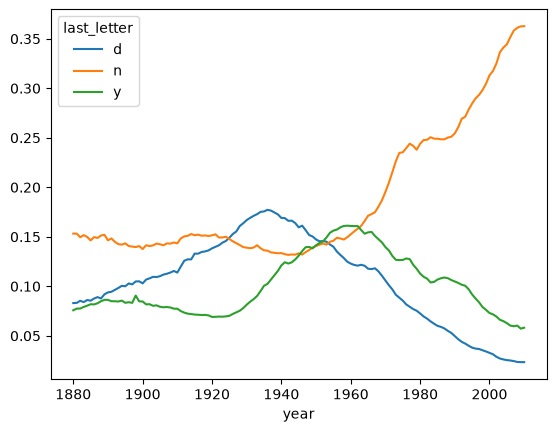

In [177]:
dny_ts.plot()

In [178]:
all_names = pd.Series(top1000['name'].unique())

In [179]:
lesley_like = all_names[all_names.str.contains('Lesl')]

In [180]:
lesley_like

654     Leslie
2307    Lesley
4257    Leslee
4725     Lesli
6096     Lesly
dtype: str

In [181]:
filtered = top1000[top1000['name'].isin(lesley_like)]

In [182]:
filtered.groupby('name')['births'].sum()

name
Leslee       993
Lesley     35009
Lesli        929
Leslie    370429
Lesly      10067
Name: births, dtype: int64

In [183]:
table = filtered.pivot_table('births', index='year',
                             columns='sex', aggfunc='sum')

In [184]:
table = table.div(table.sum(axis='columns'), axis='index')

In [185]:
table.tail()

sex,F,M
year,,
2006,1.0,NaN
2007,1.0,NaN
2008,1.0,NaN
2009,1.0,NaN
2010,1.0,NaN


<Axes: xlabel='year'>

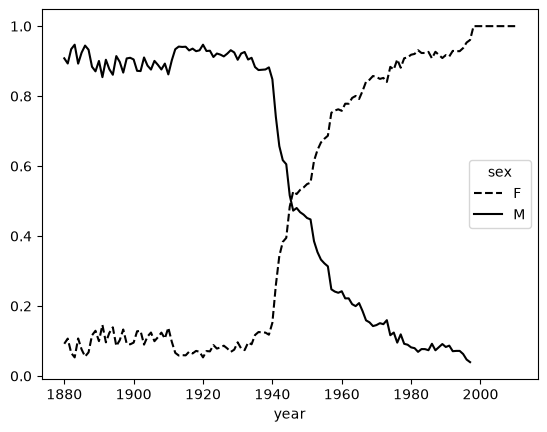

In [187]:
table.plot(style={'M': 'k-', 'F': 'k--'})